<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/v4_pipeline_of_exp8_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

drive.mount('/content/drive')

# LOAD SAVED FEATURES

X_epochs = np.load(
    os.path.join(
        OUT_DIR,
        "X_epochs.npy"
    )
)


epoch_labels = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_labels.npy"
    )
)


epoch_subjects = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_subjects.npy"
    )
)


X_norm = np.load(
    os.path.join(
        OUT_DIR,
        "X_norm.npy"
    )
)


X_pain = np.load(
    os.path.join(
        OUT_DIR,
        "X_pain.npy"
    )
)


X_hand_norm = np.load(
    os.path.join(
        OUT_DIR,
        "X_hand_norm.npy"
    )
)


X_riem = np.load(
    os.path.join(
        OUT_DIR,
        "X_riem.npy"
    )
)


print("All data loaded")
print(X_epochs.shape)
print(X_hand_norm.shape)
print(X_riem.shape)


In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
!pip -q install pymatreader mne scipy scikit-learn pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 47.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
# CELL 2 — Imports and paths

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pymatreader import read_mat
from scipy.signal import welch
from scipy.stats import skew, kurtosis

EXP_NAME = "EXP8"

# Change this path if your Exp8 folder name is different
EXP8_ROOT = "/content/drive/MyDrive/my dataset_raw_main_exp8"

OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
os.makedirs(OUT_DIR, exist_ok=True)

print("EXP8_ROOT exists:", os.path.exists(EXP8_ROOT))
print("OUT_DIR:", OUT_DIR)

EXP8_ROOT exists: True
OUT_DIR: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH


In [ ]:
# CELL 1 — Load saved V3 files

import os
import numpy as np


OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"


X_norm = np.load(
    os.path.join(
        OUT_DIR,
        "X_norm.npy"
    )
)


X_pain = np.load(
    os.path.join(
        OUT_DIR,
        "X_pain.npy"
    )
)


X_hand_norm = np.load(
    os.path.join(
        OUT_DIR,
        "X_hand_norm.npy"
    )
)


X_riem = np.load(
    os.path.join(
        OUT_DIR,
        "X_riem.npy"
    )
)


epoch_labels = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_labels.npy"
    )
)


epoch_subjects = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_subjects.npy"
    )
)



print("X_norm:",X_norm.shape)
print("X_pain:",X_pain.shape)
print("Handcrafted:",X_hand_norm.shape)
print("Riemannian:",X_riem.shape)

print("Labels:",epoch_labels.shape)
print("Subjects:",epoch_subjects.shape)

X_norm: (6275, 10, 3000)
X_pain: (6275, 10, 1000)
Handcrafted: (6275, 230)
Riemannian: (6275, 275)
Labels: (6275,)
Subjects: (6275,)


In [ ]:
# CELL 2 — Subject-wise EEG normalization


X_subject_norm = np.zeros_like(
    X_pain,
    dtype=np.float32
)



unique_subjects = np.unique(
    epoch_subjects
)



for sid in unique_subjects:


    idx = (
        epoch_subjects == sid
    )


    subject_data = X_pain[idx]


    mean = np.mean(
        subject_data,
        axis=(0,2),
        keepdims=True
    )


    std = np.std(
        subject_data,
        axis=(0,2),
        keepdims=True
    )


    X_subject_norm[idx] = (
        subject_data - mean
    ) / (std + 1e-8)



print(
    X_subject_norm.shape
)

(6275, 10, 1000)


In [ ]:
save_path = os.path.join(
    OUT_DIR,
    "X_subject_norm.npy"
)


np.save(
    save_path,
    X_subject_norm
)


print("Saved:")
print(save_path)

Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/X_subject_norm.npy


In [ ]:
!pip -q install pyriemann

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 5.5 MB/s eta 0:00:00


In [ ]:
# CELL 5 — Riemannian alignment


aligned_covs=[]


for sid in unique_subjects:


    idx = (
        epoch_subjects==sid
    )


    subject_covs = covs[idx]


    reference = mean_riemann(
        subject_covs
    )


    inv_sqrt = fractional_matrix_power(
        reference,
        -0.5
    )


    for c in subject_covs:


        aligned = (
            inv_sqrt
            @ c
            @ inv_sqrt
        )


        aligned_covs.append(
            aligned
        )



aligned_covs=np.array(
    aligned_covs
)



print(
    aligned_covs.shape
)

(6275, 10, 10)


In [ ]:
# CELL 6 — Tangent space


from pyriemann.tangentspace import TangentSpace


ts = TangentSpace(
    metric="riemann"
)


X_riem_aligned = ts.fit_transform(
    aligned_covs
)



print(
    X_riem_aligned.shape
)

(6275, 55)


In [ ]:
!pip -q install mne

In [ ]:
# CELL 7 — CSP extraction


from mne.decoding import CSP



csp = CSP(
    n_components=6,
    reg=None,
    log=True,
    norm_trace=False
)



X_csp = csp.fit_transform(
    X_subject_norm,
    epoch_labels
)



print(
    X_csp.shape
)

Computing rank from data with rank=None
    Using tolerance 14 (2.2e-16 eps * 10 dim * 6.5e+15  max singular value)
    Estimated rank (data): 10
    data: rank 10 computed from 10 data channels with 0 projectors
Reducing data rank from 10 -> 10
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
(6275, 6)


In [ ]:
# CELL 8 — Final V4 feature fusion


X_v4 = np.concatenate(
    [
        X_hand_norm,
        X_riem_aligned,
        X_csp
    ],
    axis=1
)



print(
    X_v4.shape
)

(6275, 291)


In [ ]:
save_path=os.path.join(
    OUT_DIR,
    "X_V4_fusion.npy"
)


np.save(
    save_path,
    X_v4
)


print("Saved:")
print(save_path)

Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/X_V4_fusion.npy


In [ ]:
# CELL 9 — V4 classification preparation

import os
import numpy as np
import pandas as pd


OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"


# Load V4 fused features

X_v4 = np.load(
    os.path.join(
        OUT_DIR,
        "X_V4_fusion.npy"
    )
)


epoch_labels = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_labels.npy"
    )
)


epoch_subjects = np.load(
    os.path.join(
        OUT_DIR,
        "epoch_subjects.npy"
    )
)


print("V4 features:", X_v4.shape)
print("Labels:", epoch_labels.shape)
print("Subjects:", len(np.unique(epoch_subjects)))

V4 features: (6275, 291)
Labels: (6275,)
Subjects: 223


In [ ]:
from sklearn.base import clone
from joblib import Parallel, delayed

In [ ]:
# CELL — V4 Fast Parallel LOSO Evaluation


import os
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from joblib import Parallel, delayed

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)



# =========================
# Result folder
# =========================

V4_RESULT_DIR = os.path.join(
    OUT_DIR,
    "V4_CROSS_RESULTS"
)

os.makedirs(
    V4_RESULT_DIR,
    exist_ok=True
)



# =====================================================
# Run one LOSO subject
# =====================================================


def run_one_v4_subject(
    test_subject,
    model
):


    train_idx = (
        epoch_subjects != test_subject
    )

    test_idx = (
        epoch_subjects == test_subject
    )


    X_train = X_v4[train_idx]

    X_test = X_v4[test_idx]


    y_train = epoch_labels[train_idx]

    y_test = epoch_labels[test_idx]



    # -------------------------
    # Standardization
    # training only
    # -------------------------

    scaler = StandardScaler()


    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )



    # -------------------------
    # Clone model
    # -------------------------

    clf = clone(model)



    clf.fit(
        X_train,
        y_train
    )



    y_pred = clf.predict(
        X_test
    )



    if hasattr(
        clf,
        "predict_proba"
    ):

        y_prob = clf.predict_proba(
            X_test
        )[:,1]


    elif hasattr(
        clf,
        "decision_function"
    ):

        y_prob = clf.decision_function(
            X_test
        )


    else:

        y_prob = y_pred.astype(float)



    # Subject metrics

    subject_result = {

        "subject_id": test_subject,

        "accuracy":
        accuracy_score(
            y_test,
            y_pred
        ),

        "f1":
        f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

    }


    try:

        subject_result["auc"] = roc_auc_score(
            y_test,
            y_prob
        )

    except:

        subject_result["auc"] = np.nan



    # Store predictions

    pred_rows=[]


    test_indices = np.where(test_idx)[0]


    for i,idx in enumerate(test_indices):

        pred_rows.append({

            "subject_id":
            epoch_subjects[idx],


            "true_label":
            epoch_labels[idx],


            "predicted_label":
            y_pred[i],


            "probability":
            y_prob[i]

        })


    return pred_rows, subject_result





# =====================================================
# Main LOSO function
# =====================================================


def run_v4_loso_classifier_fast(
    model,
    model_name,
    n_jobs=8
):


    print("\nRunning:", model_name)


    subjects = np.unique(
        epoch_subjects
    )


    print(
        "Subjects:",
        len(subjects)
    )



    results = Parallel(
        n_jobs=n_jobs
    )(
        delayed(run_one_v4_subject)
        (
            subject,
            model
        )

        for subject in tqdm(
            subjects,
            desc=model_name
        )
    )



    predictions=[]

    subject_results=[]


    for pred,sub in results:

        predictions.extend(pred)

        subject_results.append(sub)



    predictions_df = pd.DataFrame(
        predictions
    )


    subject_df = pd.DataFrame(
        subject_results
    )



    # =========================
    # Full classification metrics
    # =========================


    summary_df = pd.DataFrame([{

        "Model":
        model_name,


        "Accuracy":
        accuracy_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),


        "Balanced_Accuracy":
        balanced_accuracy_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),


        "Precision":
        precision_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "Recall":
        recall_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "F1":
        f1_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "ROC_AUC":
        roc_auc_score(
            predictions_df.true_label,
            predictions_df.probability
        ),


        "Mean_Subject_Accuracy":
        subject_df.accuracy.mean(),


        "Std_Subject_Accuracy":
        subject_df.accuracy.std()

    }])



    # =========================
    # Confusion matrix
    # =========================


    cm = confusion_matrix(
        predictions_df.true_label,
        predictions_df.predicted_label
    )


    cm_df = pd.DataFrame(

        cm,

        index=[
            "True_Low",
            "True_High"
        ],

        columns=[
            "Pred_Low",
            "Pred_High"
        ]

    )



    # =========================
    # Save
    # =========================


    predictions_df.to_csv(

        os.path.join(
            V4_RESULT_DIR,
            f"V4_{model_name}_predictions.csv"
        ),

        index=False
    )


    summary_df.to_csv(

        os.path.join(
            V4_RESULT_DIR,
            f"V4_{model_name}_summary.csv"
        ),

        index=False
    )


    subject_df.to_csv(

        os.path.join(
            V4_RESULT_DIR,
            f"V4_{model_name}_subject_accuracy.csv"
        ),

        index=False
    )


    cm_df.to_csv(

        os.path.join(
            V4_RESULT_DIR,
            f"V4_{model_name}_confusion_matrix.csv"
        )

    )



    print("\nSaved:")
    print(V4_RESULT_DIR)


    print("\nFinal Result:")
    display(summary_df)


    return summary_df

In [ ]:
# CELL — V4 Classifiers (Optimized)


from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from xgboost import XGBClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



models = {


    "GaussianNB":

    GaussianNB(),



    "LDA":

    LinearDiscriminantAnalysis(),



    "SVM_RBF":

    SVC(

        kernel="rbf",

        C=1,

        gamma="scale",

        # faster
        probability=False,

        class_weight="balanced",

        random_state=42

    ),



    "RandomForest":

    RandomForestClassifier(

        n_estimators=500,

        class_weight="balanced",

        random_state=42,

        n_jobs=-1

    ),



    "ExtraTrees":

    ExtraTreesClassifier(

        n_estimators=500,

        class_weight="balanced",

        random_state=42,

        n_jobs=-1

    ),



    "XGBoost":

    XGBClassifier(

        n_estimators=500,

        max_depth=3,

        learning_rate=0.03,

        subsample=0.9,

        colsample_bytree=0.9,


        eval_metric="logloss",

        random_state=42,


        # GPU acceleration
        tree_method="hist",

        device="cuda",


        n_jobs=-1

    )

}



print("Models ready:")
print(list(models.keys()))

Models ready:
['GaussianNB', 'LDA', 'SVM_RBF', 'RandomForest', 'ExtraTrees', 'XGBoost']


In [ ]:
svm_result = run_v4_loso_classifier_fast(
    models["SVM_RBF"],
    "SVM_RBF",
    n_jobs=8
)


Running: SVM_RBF
Subjects: 223


SVM_RBF: 100%|██████████| 223/223 [09:44<00:00,  2.62s/it]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS

Final Result:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Subject_Accuracy,Std_Subject_Accuracy
0,SVM_RBF,0.646056,0.650213,0.716944,0.618592,0.664146,0.686427,0.646951,0.182659


In [ ]:
rf_result = run_v4_loso_classifier_fast(
    models["RandomForest"],
    "RandomForest",
    n_jobs=8
)


Running: RandomForest
Subjects: 223


RandomForest: 100%|██████████| 223/223 [54:07<00:00, 14.56s/it]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS

Final Result:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Subject_Accuracy,Std_Subject_Accuracy
0,RandomForest,0.638247,0.624379,0.664018,0.729859,0.695384,0.685789,0.638669,0.183302


In [ ]:
et_result = run_v4_loso_classifier_fast(
    models["ExtraTrees"],
    "ExtraTrees",
    n_jobs=8
)


Running: ExtraTrees
Subjects: 223


ExtraTrees: 100%|██████████| 223/223 [10:21<00:00,  2.79s/it]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS

Final Result:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Subject_Accuracy,Std_Subject_Accuracy
0,ExtraTrees,0.644303,0.631693,0.671258,0.727606,0.698297,0.690785,0.644189,0.181951


In [ ]:
xgb_result = run_v4_loso_classifier_fast(
    models["XGBoost"],
    "XGBoost_GPU",
    n_jobs=1
)


Running: XGBoost_GPU
Subjects: 223


XGBoost_GPU: 100%|██████████| 223/223 [02:02<00:00,  1.82it/s]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS

Final Result:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Subject_Accuracy,Std_Subject_Accuracy
0,XGBoost_GPU,0.642869,0.632088,0.674023,0.714085,0.693476,0.687217,0.643057,0.164036


In [ ]:
lda_result = run_v4_loso_classifier_fast(
    models["LDA"],
    "LDA",
    n_jobs=8
)


Running: LDA
Subjects: 223


LDA: 100%|██████████| 223/223 [00:18<00:00, 12.32it/s]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS

Final Result:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Subject_Accuracy,Std_Subject_Accuracy
0,LDA,0.626773,0.615816,0.660809,0.699155,0.679442,0.667352,0.627616,0.155935


In [ ]:
gaussian_result = run_v4_loso_classifier_fast(
    models["GaussianNB"],
    "GaussianNB",
    n_jobs=8
)


Running: GaussianNB
Subjects: 223


GaussianNB: 100%|██████████| 223/223 [00:06<00:00, 35.78it/s]



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS

Final Result:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Subject_Accuracy,Std_Subject_Accuracy
0,GaussianNB,0.599522,0.620472,0.731784,0.461127,0.565751,0.668059,0.599726,0.215495


In [ ]:
# CELL — V4 Cross Results Summary


import glob
import pandas as pd
import os



summary_files = glob.glob(

    os.path.join(

        V4_RESULT_DIR,

        "*_summary.csv"

    )

)



print(
    "Found:",
    len(summary_files),
    "models"
)



v4_all_results = pd.concat(

    [

        pd.read_csv(f)

        for f in summary_files

    ],

    ignore_index=True

)



v4_all_results = v4_all_results.sort_values(

    by="Accuracy",

    ascending=False

)



display(
    v4_all_results
)



save_path = os.path.join(

    V4_RESULT_DIR,

    "V4_ALL_CLASSIFIER_COMPARISON.csv"

)



v4_all_results.to_csv(

    save_path,

    index=False

)



print("\nSaved:")
print(save_path)

Found: 6 models


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Subject_Accuracy,Std_Subject_Accuracy
0,SVM_RBF,0.646056,0.650213,0.716944,0.618592,0.664146,0.686427,0.646951,0.182659
2,ExtraTrees,0.644303,0.631693,0.671258,0.727606,0.698297,0.690785,0.644189,0.181951
5,XGBoost_GPU,0.642869,0.632088,0.674023,0.714085,0.693476,0.687217,0.643057,0.164036
1,RandomForest,0.638247,0.624379,0.664018,0.729859,0.695384,0.685789,0.638669,0.183302
3,LDA,0.626773,0.615816,0.660809,0.699155,0.679442,0.667352,0.627616,0.155935
4,GaussianNB,0.599522,0.620472,0.731784,0.461127,0.565751,0.668059,0.599726,0.215495



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS/V4_ALL_CLASSIFIER_COMPARISON.csv


In [ ]:
# CELL — V4 Final Ensemble LOSO (Fast + Full Metrics + GPU XGBoost)

import os
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier

from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)



ENSEMBLE_DIR = os.path.join(
    OUT_DIR,
    "V4_FINAL_ENSEMBLE_RESULTS"
)


os.makedirs(
    ENSEMBLE_DIR,
    exist_ok=True
)



def run_v4_final_ensemble_full_metrics():


    predictions = []

    subject_results = []


    subjects = np.unique(
        epoch_subjects
    )


    print("\nRunning V4 Final Ensemble")

    print(
        "Subjects:",
        len(subjects)
    )



    for test_subject in tqdm(
        subjects,
        desc="V4 Ensemble"
    ):


        # =========================
        # LOSO split
        # =========================


        train_idx = (
            epoch_subjects != test_subject
        )


        test_idx = (
            epoch_subjects == test_subject
        )



        X_train = X_v4[
            train_idx
        ]


        X_test = X_v4[
            test_idx
        ]


        y_train = epoch_labels[
            train_idx
        ]


        y_test = epoch_labels[
            test_idx
        ]



        # =========================
        # Standardization
        # =========================


        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X_train
        )


        X_test = scaler.transform(
            X_test
        )



        # =========================
        # Fresh models per fold
        # =========================


        svm = SVC(

            kernel="rbf",

            C=1,

            gamma="scale",

            probability=True,

            class_weight="balanced",

            random_state=42

        )



        extra = ExtraTreesClassifier(

            n_estimators=500,

            class_weight="balanced",

            random_state=42,

            n_jobs=-1

        )



        xgb = XGBClassifier(

            n_estimators=500,

            max_depth=3,

            learning_rate=0.03,

            subsample=0.9,

            colsample_bytree=0.9,

            eval_metric="logloss",

            random_state=42,

            n_jobs=-1,

            tree_method="hist",

            device="cuda"

        )



        # =========================
        # Train
        # =========================


        if len(np.unique(y_train)) < 2:

            final_pred = np.ones(
                len(y_test)
            ) * y_train[0]

            final_prob = final_pred


            svm_prob = final_prob
            extra_prob = final_prob
            xgb_prob = final_prob



        else:


            svm.fit(
                X_train,
                y_train
            )


            extra.fit(
                X_train,
                y_train
            )


            xgb.fit(
                X_train,
                y_train
            )



            # probabilities


            svm_prob = svm.predict_proba(
                X_test
            )[:,1]


            extra_prob = extra.predict_proba(
                X_test
            )[:,1]


            xgb_prob = xgb.predict_proba(
                X_test
            )[:,1]



            # weighted fusion


            final_prob = (

                0.35 * svm_prob

                +

                0.35 * extra_prob

                +

                0.30 * xgb_prob

            )


            final_pred = (
                final_prob >= 0.5
            ).astype(int)



        # =========================
        # Subject metrics
        # =========================


        try:

            auc = roc_auc_score(
                y_test,
                final_prob
            )

        except:

            auc = np.nan



        subject_results.append({

            "subject_id":
            test_subject,


            "accuracy":
            accuracy_score(
                y_test,
                final_pred
            ),


            "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                final_pred
            ),


            "precision":
            precision_score(
                y_test,
                final_pred,
                zero_division=0
            ),


            "recall":
            recall_score(
                y_test,
                final_pred,
                zero_division=0
            ),


            "f1":
            f1_score(
                y_test,
                final_pred,
                zero_division=0
            ),


            "roc_auc":
            auc

        })



        # =========================
        # Trial predictions
        # =========================


        for i, idx in enumerate(
            np.where(test_idx)[0]
        ):


            predictions.append({

                "subject_id":
                epoch_subjects[idx],


                "true_label":
                epoch_labels[idx],


                "predicted_label":
                final_pred[i],


                "probability":
                final_prob[i],


                "svm_probability":
                svm_prob[i],


                "extra_probability":
                extra_prob[i],


                "xgb_probability":
                xgb_prob[i]

            })



    # =========================
    # DataFrames
    # =========================


    predictions_df = pd.DataFrame(
        predictions
    )


    subject_df = pd.DataFrame(
        subject_results
    )



    # =========================
    # Final summary
    # =========================


    summary_df = pd.DataFrame([{

        "Model":
        "V4_Ensemble_SVM_ExtraTrees_XGB",


        "Weights":
        "SVM=0.35, ExtraTrees=0.35, XGB=0.30",


        "Subjects_used":
        len(subjects),


        "Mean_Subject_Accuracy":
        subject_df.accuracy.mean(),


        "Std_Subject_Accuracy":
        subject_df.accuracy.std(),


        "Accuracy":
        accuracy_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),


        "Balanced_Accuracy":
        balanced_accuracy_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),


        "Precision":
        precision_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "Recall":
        recall_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "F1":
        f1_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "ROC_AUC":
        roc_auc_score(
            predictions_df.true_label,
            predictions_df.probability
        )

    }])



    # =========================
    # Confusion matrix
    # =========================


    cm = confusion_matrix(

        predictions_df.true_label,

        predictions_df.predicted_label

    )


    cm_df = pd.DataFrame(

        cm,

        index=[
            "True_Low",
            "True_High"
        ],

        columns=[
            "Pred_Low",
            "Pred_High"
        ]

    )



    # =========================
    # Save
    # =========================


    predictions_df.to_csv(
        os.path.join(
            ENSEMBLE_DIR,
            "V4_Final_Ensemble_predictions.csv"
        ),
        index=False
    )


    summary_df.to_csv(
        os.path.join(
            ENSEMBLE_DIR,
            "V4_Final_Ensemble_summary.csv"
        ),
        index=False
    )


    subject_df.to_csv(
        os.path.join(
            ENSEMBLE_DIR,
            "V4_Final_Ensemble_subject_accuracy.csv"
        ),
        index=False
    )


    cm_df.to_csv(
        os.path.join(
            ENSEMBLE_DIR,
            "V4_Final_Ensemble_confusion_matrix.csv"
        )
    )


    print("\nSaved all ensemble results:")
    print(ENSEMBLE_DIR)


    display(summary_df)


    return summary_df

In [ ]:
v4_ensemble_result = run_v4_final_ensemble_full_metrics()


Running V4 Final Ensemble
Subjects: 223


V4 Ensemble: 100%|██████████| 223/223 [2:45:32<00:00, 44.54s/it]



Saved all ensemble results:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_FINAL_ENSEMBLE_RESULTS


,Model,Weights,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,V4_Ensemble_SVM_ExtraTrees_XGB,"SVM=0.35, ExtraTrees=0.35, XGB=0.30",223,0.648675,0.175227,0.648287,0.637815,0.679019,0.717465,0.697713,0.695805


In [ ]:
import os

# Path to your V4_CROSS_RESULTS folder
v4_cross_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS"

# List all files
all_files = os.listdir(v4_cross_dir)
all_files.sort()  # optional: sort alphabetically

print(f"Found {len(all_files)} files:")
for f in all_files:
    print(f)

Found 26 files:
PRIMARY_230_CROSS_ALL_MODELS.csv
V4_ALL_CLASSIFIER_COMPARISON.csv
V4_ExtraTrees_confusion_matrix.csv
V4_ExtraTrees_predictions.csv
V4_ExtraTrees_subject_accuracy.csv
V4_ExtraTrees_summary.csv
V4_GaussianNB_confusion_matrix.csv
V4_GaussianNB_predictions.csv
V4_GaussianNB_subject_accuracy.csv
V4_GaussianNB_summary.csv
V4_LDA_confusion_matrix.csv
V4_LDA_predictions.csv
V4_LDA_subject_accuracy.csv
V4_LDA_summary.csv
V4_RandomForest_confusion_matrix.csv
V4_RandomForest_predictions.csv
V4_RandomForest_subject_accuracy.csv
V4_RandomForest_summary.csv
V4_SVM_RBF_confusion_matrix.csv
V4_SVM_RBF_predictions.csv
V4_SVM_RBF_subject_accuracy.csv
V4_SVM_RBF_summary.csv
V4_XGBoost_GPU_confusion_matrix.csv
V4_XGBoost_GPU_predictions.csv
V4_XGBoost_GPU_subject_accuracy.csv
V4_XGBoost_GPU_summary.csv


In [ ]:
import os
import glob
import pandas as pd

# -------------------------------
# Paths to the folders
# -------------------------------
cross_results_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS"
ensemble_results_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_FINAL_ENSEMBLE_RESULTS"

# -------------------------------
# List of all 6 model summary files
# -------------------------------
model_files = [
    "V4_SVM_RBF_summary.csv",
    "V4_RandomForest_summary.csv",
    "V4_ExtraTrees_summary.csv",
    "V4_XGBoost_GPU_summary.csv",
    "V4_LDA_summary.csv",
    "V4_GaussianNB_summary.csv"
]

# -------------------------------
# Load 6 models
# -------------------------------
dfs = []
for f in model_files:
    path = os.path.join(cross_results_dir, f)
    if os.path.exists(path):
        df = pd.read_csv(path)
        dfs.append(df)
    else:
        print(f"Warning: {f} not found!")

# -------------------------------
# Load Ensemble
# -------------------------------
ensemble_file = os.path.join(ensemble_results_dir, "V4_Final_Ensemble_summary.csv")
if os.path.exists(ensemble_file):
    df_ensemble = pd.read_csv(ensemble_file)
    dfs.append(df_ensemble)
else:
    print("Warning: Ensemble summary file not found!")

# -------------------------------
# Concatenate all 7 models
# -------------------------------
all_models_df = pd.concat(dfs, ignore_index=True)

# Optional: reorder columns for consistency
desired_cols = [
    "Model", "Weights", "Subjects_used", "Mean_Subject_Accuracy", "Std_Subject_Accuracy",
    "Accuracy", "Balanced_Accuracy", "Precision", "Recall", "F1", "ROC_AUC"
]

# Keep only columns that exist
existing_cols = [c for c in desired_cols if c in all_models_df.columns]
all_models_df = all_models_df[existing_cols]

# -------------------------------
# Sort by Accuracy descending
# -------------------------------
all_models_df = all_models_df.sort_values(by="Accuracy", ascending=False)

# -------------------------------
# Save consolidated table
# -------------------------------
output_file = os.path.join(cross_results_dir, "PRIMARY_230_CROSS_ALL_MODELS.csv")
all_models_df.to_csv(output_file, index=False)

print("Consolidated cross-individual results saved to:", output_file)
display(all_models_df)

Consolidated cross-individual results saved to: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS/PRIMARY_230_CROSS_ALL_MODELS.csv


,Model,Weights,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
6,V4_Ensemble_SVM_ExtraTrees_XGB,"SVM=0.35, ExtraTrees=0.35, XGB=0.30",223.0,0.648675,0.175227,0.648287,0.637815,0.679019,0.717465,0.697713,0.695805
0,SVM_RBF,NaN,NaN,0.646951,0.182659,0.646056,0.650213,0.716944,0.618592,0.664146,0.686427
2,ExtraTrees,NaN,NaN,0.644189,0.181951,0.644303,0.631693,0.671258,0.727606,0.698297,0.690785
3,XGBoost_GPU,NaN,NaN,0.643057,0.164036,0.642869,0.632088,0.674023,0.714085,0.693476,0.687217
1,RandomForest,NaN,NaN,0.638669,0.183302,0.638247,0.624379,0.664018,0.729859,0.695384,0.685789
4,LDA,NaN,NaN,0.627616,0.155935,0.626773,0.615816,0.660809,0.699155,0.679442,0.667352
5,GaussianNB,NaN,NaN,0.599726,0.215495,0.599522,0.620472,0.731784,0.461127,0.565751,0.668059


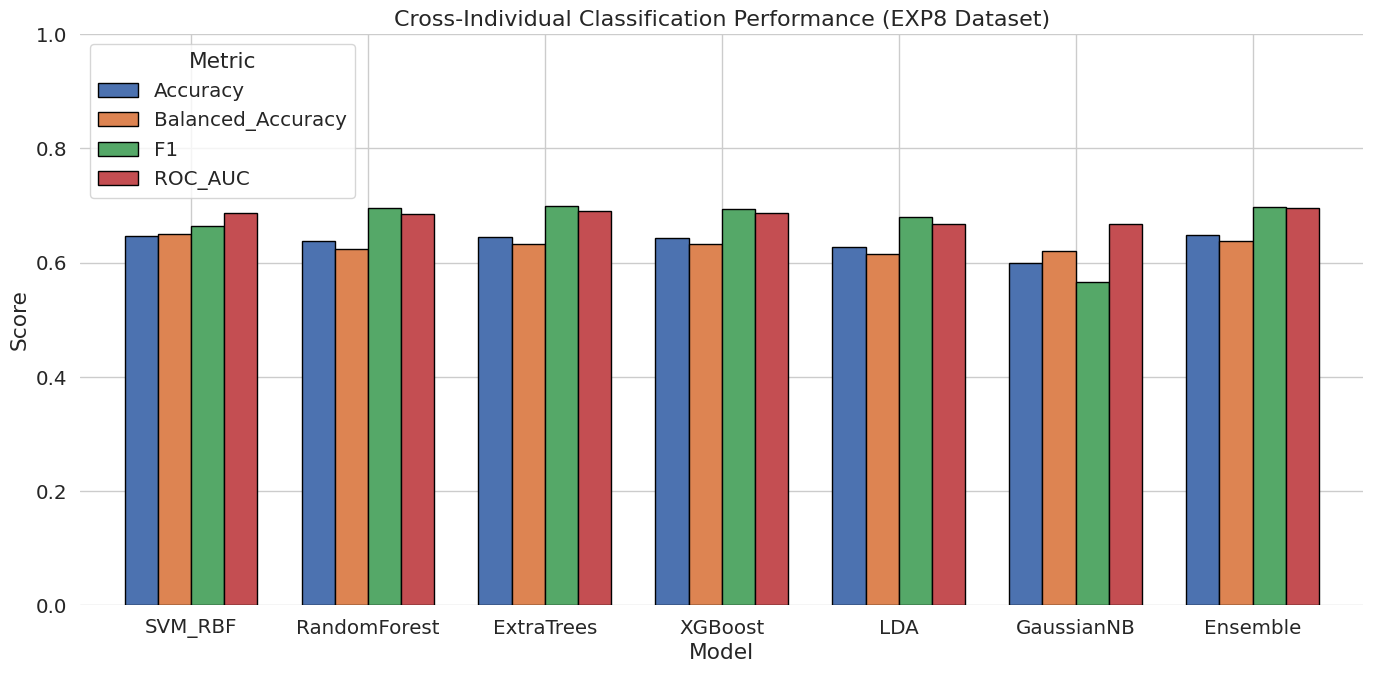

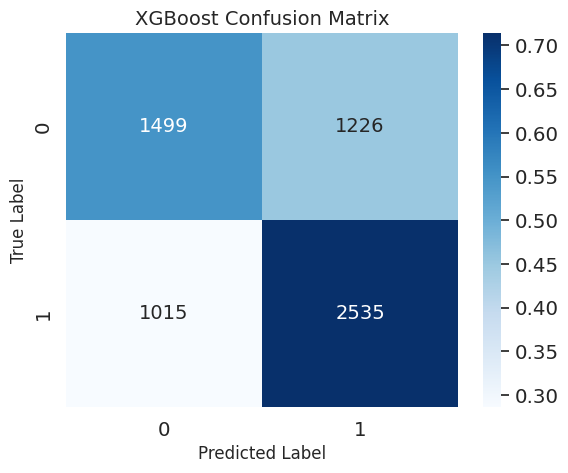

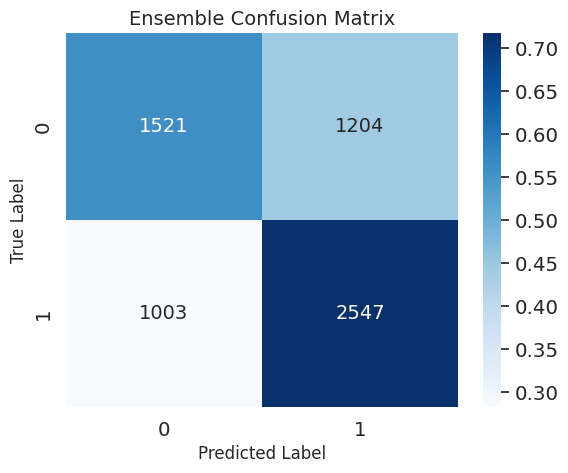

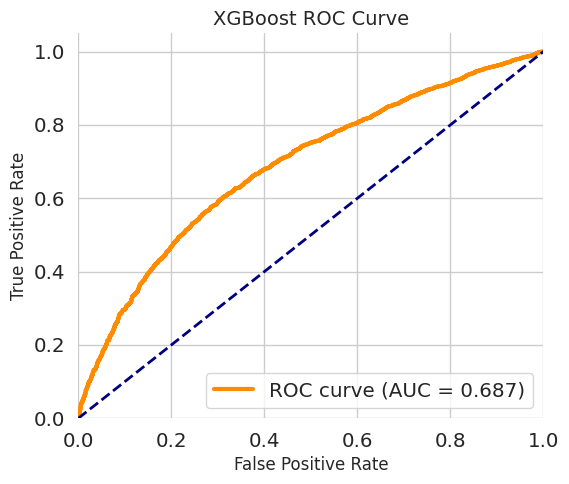

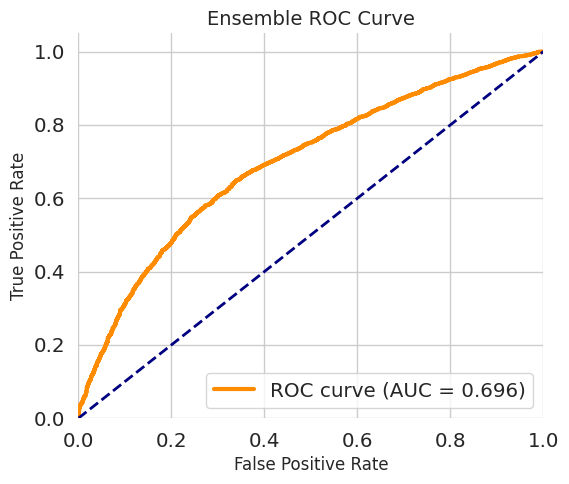

In [ ]:
# =========================
# Premium Visualization for Thesis / Publication
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set(style="whitegrid", font_scale=1.3)
plt.rcParams["figure.figsize"] = (12,7)

# -------------------------
# Paths to the CSVs
# -------------------------
cross_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS"
ensemble_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_FINAL_ENSEMBLE_RESULTS"

# 6 individual model summary CSVs
models = ["SVM_RBF", "RandomForest", "ExtraTrees", "XGBoost_GPU", "LDA", "GaussianNB"]
model_summaries = [os.path.join(cross_dir, f"V4_{m}_summary.csv") for m in models]

# Ensemble summary
ensemble_summary = os.path.join(ensemble_dir, "V4_Final_Ensemble_summary.csv")

# -------------------------
# Load summaries and merge
# -------------------------
dfs = [pd.read_csv(f) for f in model_summaries]
ensemble_df = pd.read_csv(ensemble_summary)

# Add ensemble as last row
dfs.append(ensemble_df)
all_models_df = pd.concat(dfs, ignore_index=True)

# Rename for publication clarity
all_models_df["Model"] = all_models_df["Model"].replace({
    "XGBoost_GPU":"XGBoost",
    "V4_Ensemble_SVM_ExtraTrees_XGB":"Ensemble"
})

# -------------------------
# Bar plot: Multiple metrics side by side
# -------------------------
metrics = ["Accuracy", "Balanced_Accuracy", "F1", "ROC_AUC"]
all_models_df_plot = all_models_df[["Model"] + metrics].set_index("Model")

fig, ax = plt.subplots(figsize=(14,7))
all_models_df_plot.plot(kind="bar", ax=ax, rot=0, width=0.75, edgecolor='black')

ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Cross-Individual Classification Performance (EXP8 Dataset)", fontsize=16)
ax.legend(title="Metric", loc="upper left")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# -------------------------
# Confusion Matrix Plotting Function
# -------------------------
def plot_conf_matrix(pred_file, model_name, save_path=None):
    df = pd.read_csv(pred_file)
    cm = confusion_matrix(df["true_label"], df["predicted_label"])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=cm, fmt='g', cmap="Blues", cbar=True, annot_kws={"size":14})
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(f"{model_name} Confusion Matrix", fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

# -------------------------
# ROC Curve Plotting Function
# -------------------------
def plot_roc_curve(pred_file, model_name, save_path=None):
    df = pd.read_csv(pred_file)
    fpr, tpr, _ = roc_curve(df["true_label"], df["probability"])
    roc_auc_val = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{model_name} ROC Curve', fontsize=14)
    plt.legend(loc="lower right")
    sns.despine(left=True, bottom=True)
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

# -------------------------
# Example: Plot confusion matrix and ROC for XGBoost and Ensemble
# -------------------------
xgb_pred_file = os.path.join(cross_dir, "V4_XGBoost_GPU_predictions.csv")
ensemble_pred_file = os.path.join(ensemble_dir, "V4_Final_Ensemble_predictions.csv")

plot_conf_matrix(xgb_pred_file, "XGBoost")
plot_conf_matrix(ensemble_pred_file, "Ensemble")

plot_roc_curve(xgb_pred_file, "XGBoost")
plot_roc_curve(ensemble_pred_file, "Ensemble")

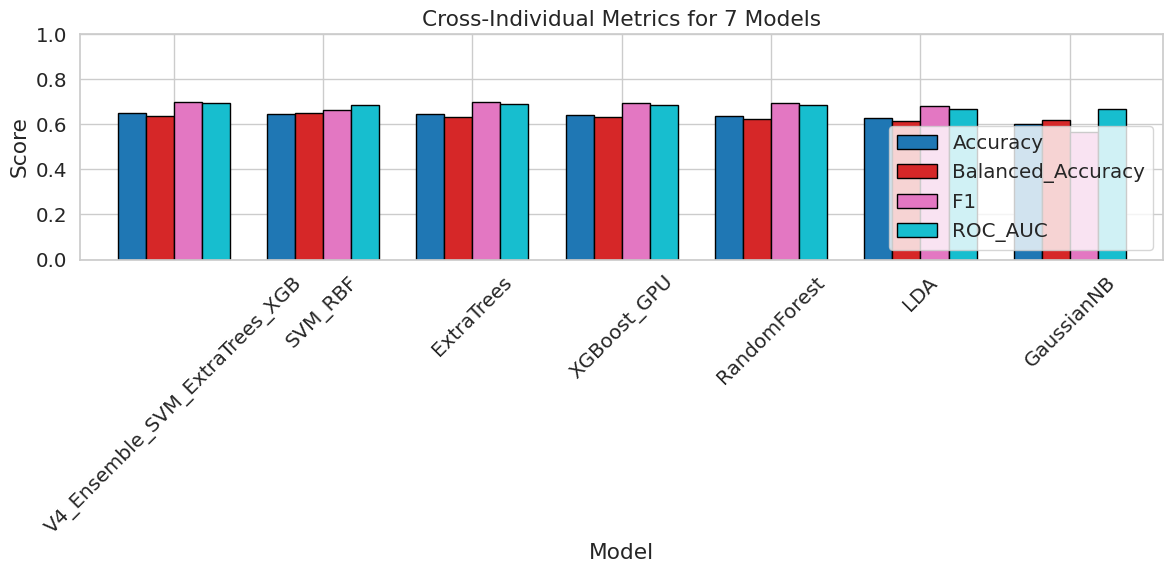

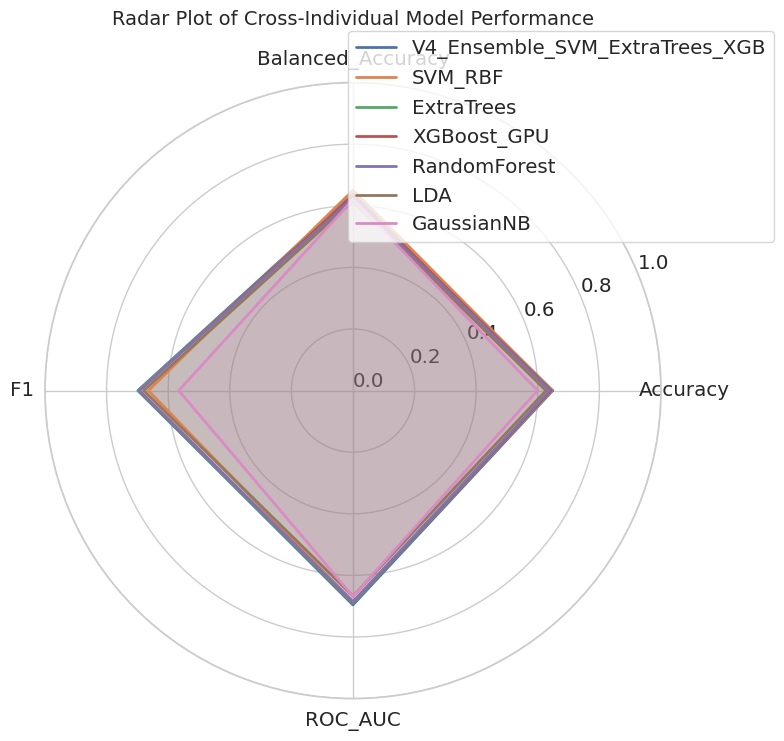

Predictions CSV for V4_Ensemble_SVM_ExtraTrees_XGB not found!


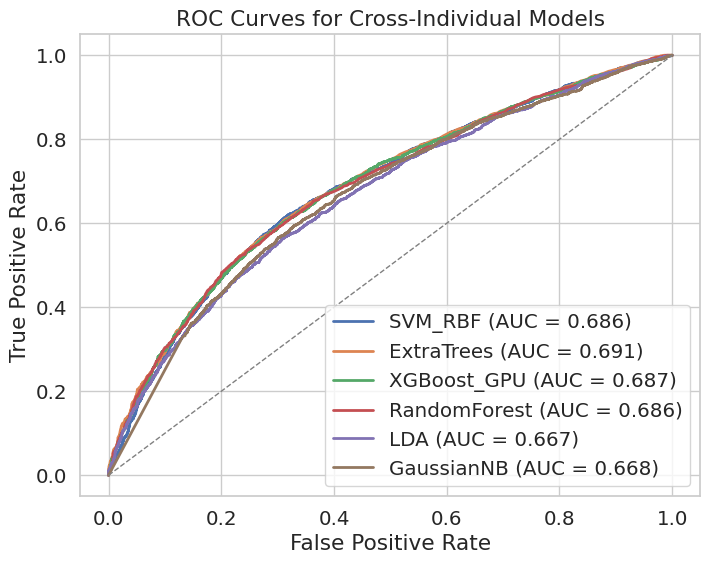

In [ ]:
# =========================
# Premium Visualization for 7-model results
# =========================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set(style="whitegrid", font_scale=1.3)
plt.rcParams["figure.figsize"] = (12,6)

# ------------------------
# Load consolidated results
# ------------------------
cross_results_file = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS/PRIMARY_230_CROSS_ALL_MODELS.csv"
all_models_df = pd.read_csv(cross_results_file)

# ------------------------
# Bar plot for key metrics
# ------------------------
metrics = ["Accuracy", "Balanced_Accuracy", "F1", "ROC_AUC"]
df_plot = all_models_df.set_index("Model")[metrics].sort_values("Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(12,6))
df_plot.plot(kind="bar", rot=45, ax=ax, width=0.75, edgecolor="black", colormap="tab10")
ax.set_ylabel("Score")
ax.set_ylim(0,1)
ax.set_title("Cross-Individual Metrics for 7 Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ------------------------
# Radar plot for multi-metric comparison
# ------------------------
def radar_plot(df, metrics, title):
    import matplotlib.pyplot as plt
    import numpy as np

    categories = metrics
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

    for i, row in df.iterrows():
        values = row[metrics].tolist()
        values += values[:1]
        ax.plot(angles, values, label=row["Model"], linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_yticks(np.linspace(0,1,6))
    ax.set_yticklabels([f"{x:.1f}" for x in np.linspace(0,1,6)])
    ax.set_title(title, size=14, y=1.08)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2,1.1))
    plt.show()

radar_plot(all_models_df, metrics, "Radar Plot of Cross-Individual Model Performance")

# ------------------------
# Confusion Matrix Example (Best Model)
# ------------------------
best_model = all_models_df.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
pred_file = f"/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS/V4_{best_model}_predictions.csv"

if os.path.exists(pred_file):
    pred_df = pd.read_csv(pred_file)
    cm = confusion_matrix(pred_df["true_label"], pred_df["predicted_label"])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=cm, fmt='g', cmap="Blues", cbar=True)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{best_model} Confusion Matrix (Normalized)")
    plt.show()
else:
    print(f"Predictions CSV for {best_model} not found!")

# ------------------------
# Optional: ROC curve plotting for multiple models
# ------------------------
def plot_roc(pred_files, model_names):
    plt.figure(figsize=(8,6))
    for f, name in zip(pred_files, model_names):
        if os.path.exists(f):
            df = pd.read_csv(f)
            fpr, tpr, _ = roc_curve(df["true_label"], df["probability"])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1], color="gray", lw=1, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for Cross-Individual Models")
    plt.legend(loc="lower right")
    plt.show()

pred_files = [
    f"/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_CROSS_RESULTS/V4_{m}_predictions.csv"
    for m in all_models_df["Model"]
]
plot_roc(pred_files, all_models_df["Model"].tolist())

In [ ]:
# # CELL — V4 Within Individual LOOCV (Fast + Full Metrics with GPU for XGBoost)

# import os
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import LeaveOneOut
# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     confusion_matrix
# )

# WITHIN_RESULT_DIR = os.path.join(OUT_DIR, "V4_WITHIN_RESULTS")
# os.makedirs(WITHIN_RESULT_DIR, exist_ok=True)

# def run_v4_within_loso_full_metrics(model, model_name):
#     predictions = []
#     subject_results = []

#     # Only subjects with both classes
#     subjects = [sid for sid in np.unique(epoch_subjects) if len(np.unique(epoch_labels[epoch_subjects==sid])) == 2]
#     print(f"\nRunning: {model_name}")
#     print("Valid subjects for LOOCV:", len(subjects))
#     print("Excluded single-class subjects:", len(np.unique(epoch_subjects)) - len(subjects))

#     for sid in tqdm(subjects, desc=model_name):
#         idx = epoch_subjects == sid
#         X_sub, y_sub = X_v4[idx], epoch_labels[idx]
#         loo = LeaveOneOut()
#         y_true_sub, y_pred_sub, y_prob_sub = [], [], []

#         for train_idx, test_idx in loo.split(X_sub):
#             X_train, X_test = X_sub[train_idx], X_sub[test_idx]
#             y_train, y_test = y_sub[train_idx], y_sub[test_idx]

#             # Standardize
#             scaler = StandardScaler()
#             X_train = scaler.fit_transform(X_train)
#             X_test = scaler.transform(X_test)

#             # Handle single-class fold
#             if len(np.unique(y_train)) < 2:
#                 pred = y_train[0]
#                 prob = float(pred)
#             else:
#                 # GPU-enabled XGBoost
#                 if "XGBClassifier" in str(type(model)):
#                     model.set_params(tree_method="gpu_hist")
#                 model.fit(X_train, y_train)
#                 pred = model.predict(X_test)[0]

#                 if hasattr(model, "predict_proba"):
#                     proba = model.predict_proba(X_test)
#                     prob = proba[0,1] if proba.shape[1] == 2 else float(model.classes_[0])
#                 elif hasattr(model, "decision_function"):
#                     prob = model.decision_function(X_test)[0]
#                 else:
#                     prob = float(pred)

#             y_true_sub.append(y_test[0])
#             y_pred_sub.append(pred)
#             y_prob_sub.append(prob)

#             predictions.append({
#                 "subject_id": sid,
#                 "true_label": y_test[0],
#                 "predicted_label": pred,
#                 "probability": prob
#             })

#         # Subject metrics
#         try:
#             subject_auc = roc_auc_score(y_true_sub, y_prob_sub)
#         except:
#             subject_auc = np.nan

#         subject_results.append({
#             "subject_id": sid,
#             "accuracy": accuracy_score(y_true_sub, y_pred_sub),
#             "balanced_accuracy": balanced_accuracy_score(y_true_sub, y_pred_sub),
#             "precision": precision_score(y_true_sub, y_pred_sub, zero_division=0),
#             "recall": recall_score(y_true_sub, y_pred_sub, zero_division=0),
#             "f1": f1_score(y_true_sub, y_pred_sub, zero_division=0),
#             "auc": subject_auc
#         })

#     # Convert to DataFrames
#     predictions_df = pd.DataFrame(predictions)
#     subject_df = pd.DataFrame(subject_results)

#     # Overall metrics
#     summary_df = pd.DataFrame([{
#         "Model": model_name,
#         "Subjects_used": len(subjects),
#         "Mean_Subject_Accuracy": subject_df.accuracy.mean(),
#         "Std_Subject_Accuracy": subject_df.accuracy.std(),
#         "Accuracy": accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
#         "Balanced_Accuracy": balanced_accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
#         "Precision": precision_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
#         "Recall": recall_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
#         "F1": f1_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
#         "ROC_AUC": roc_auc_score(predictions_df.true_label, predictions_df.probability)
#     }])

#     # Confusion matrix
#     cm = confusion_matrix(predictions_df.true_label, predictions_df.predicted_label)
#     cm_df = pd.DataFrame(cm, index=["True_Low","True_High"], columns=["Pred_Low","Pred_High"])

#     # Save
#     predictions_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V4_WITHIN_{model_name}_predictions.csv"), index=False)
#     summary_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V4_WITHIN_{model_name}_summary.csv"), index=False)
#     subject_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V4_WITHIN_{model_name}_subject_accuracy.csv"), index=False)
#     cm_df.to_csv(os.path.join(WITHIN_RESULT_DIR, f"V4_WITHIN_{model_name}_confusion_matrix.csv"))

#     print("\nSaved all files for:", model_name)
#     display(summary_df)

#     return summary_df

In [ ]:
# CELL — V4 Within Individual LOOCV (Fast + Full Metrics)

import os
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


WITHIN_RESULT_DIR = os.path.join(
    OUT_DIR,
    "V4_WITHIN_RESULTS"
)

os.makedirs(
    WITHIN_RESULT_DIR,
    exist_ok=True
)



def run_v4_within_loso_full_metrics(
    model,
    model_name
):

    predictions = []
    subject_results = []


    # Only binary subjects

    subjects = [

        sid

        for sid in np.unique(epoch_subjects)

        if len(
            np.unique(
                epoch_labels[epoch_subjects == sid]
            )
        ) == 2

    ]


    print(f"\nRunning: {model_name}")

    print(
        "Valid subjects for LOOCV:",
        len(subjects)
    )

    print(
        "Excluded single-class subjects:",
        len(np.unique(epoch_subjects))-len(subjects)
    )



    for sid in tqdm(
        subjects,
        desc=model_name
    ):


        idx = epoch_subjects == sid


        X_sub = X_v4[idx]

        y_sub = epoch_labels[idx]


        loo = LeaveOneOut()


        y_true_sub = []
        y_pred_sub = []
        y_prob_sub = []



        for train_idx, test_idx in loo.split(X_sub):


            X_train = X_sub[train_idx]

            X_test = X_sub[test_idx]


            y_train = y_sub[train_idx]

            y_test = y_sub[test_idx]



            # Standardization only from training data

            scaler = StandardScaler()


            X_train = scaler.fit_transform(
                X_train
            )


            X_test = scaler.transform(
                X_test
            )



            # Single class handling

            if len(
                np.unique(y_train)
            ) < 2:


                pred = y_train[0]

                prob = float(pred)



            else:


                # IMPORTANT:
                # Do NOT change tree_method here.
                # GPU is already configured in XGBClassifier.

                model.fit(
                    X_train,
                    y_train
                )


                pred = model.predict(
                    X_test
                )[0]



                if hasattr(
                    model,
                    "predict_proba"
                ):


                    proba = model.predict_proba(
                        X_test
                    )


                    if proba.shape[1] == 2:

                        prob = proba[0,1]

                    else:

                        prob = float(
                            model.classes_[0]
                        )



                elif hasattr(
                    model,
                    "decision_function"
                ):


                    prob = model.decision_function(
                        X_test
                    )[0]


                else:

                    prob = float(pred)



            y_true_sub.append(
                y_test[0]
            )

            y_pred_sub.append(
                pred
            )

            y_prob_sub.append(
                prob
            )



            predictions.append({

                "subject_id": sid,

                "true_label": y_test[0],

                "predicted_label": pred,

                "probability": prob

            })



        # Subject metrics

        try:

            subject_auc = roc_auc_score(
                y_true_sub,
                y_prob_sub
            )

        except:

            subject_auc = np.nan



        subject_results.append({

            "subject_id": sid,

            "accuracy": accuracy_score(
                y_true_sub,
                y_pred_sub
            ),

            "balanced_accuracy": balanced_accuracy_score(
                y_true_sub,
                y_pred_sub
            ),

            "precision": precision_score(
                y_true_sub,
                y_pred_sub,
                zero_division=0
            ),

            "recall": recall_score(
                y_true_sub,
                y_pred_sub,
                zero_division=0
            ),

            "f1": f1_score(
                y_true_sub,
                y_pred_sub,
                zero_division=0
            ),

            "auc": subject_auc

        })



    predictions_df = pd.DataFrame(
        predictions
    )


    subject_df = pd.DataFrame(
        subject_results
    )



    summary_df = pd.DataFrame([{

        "Model": model_name,

        "Subjects_used": len(subjects),


        "Mean_Subject_Accuracy":
        subject_df.accuracy.mean(),


        "Std_Subject_Accuracy":
        subject_df.accuracy.std(),


        "Accuracy":
        accuracy_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),


        "Balanced_Accuracy":
        balanced_accuracy_score(
            predictions_df.true_label,
            predictions_df.predicted_label
        ),


        "Precision":
        precision_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "Recall":
        recall_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "F1":
        f1_score(
            predictions_df.true_label,
            predictions_df.predicted_label,
            zero_division=0
        ),


        "ROC_AUC":
        roc_auc_score(
            predictions_df.true_label,
            predictions_df.probability
        )

    }])



    cm = confusion_matrix(
        predictions_df.true_label,
        predictions_df.predicted_label
    )


    cm_df = pd.DataFrame(

        cm,

        index=[
            "True_Low",
            "True_High"
        ],

        columns=[
            "Pred_Low",
            "Pred_High"
        ]

    )



    predictions_df.to_csv(
        os.path.join(
            WITHIN_RESULT_DIR,
            f"V4_WITHIN_{model_name}_predictions.csv"
        ),
        index=False
    )


    summary_df.to_csv(
        os.path.join(
            WITHIN_RESULT_DIR,
            f"V4_WITHIN_{model_name}_summary.csv"
        ),
        index=False
    )


    subject_df.to_csv(
        os.path.join(
            WITHIN_RESULT_DIR,
            f"V4_WITHIN_{model_name}_subject_accuracy.csv"
        ),
        index=False
    )


    cm_df.to_csv(
        os.path.join(
            WITHIN_RESULT_DIR,
            f"V4_WITHIN_{model_name}_confusion_matrix.csv"
        )
    )



    print("\nSaved all files for:", model_name)

    display(summary_df)


    return summary_df

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb_within = run_v4_within_loso_full_metrics(
    gnb,
    "GaussianNB"
)


Running: GaussianNB
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


GaussianNB: 100%|██████████| 205/205 [00:17<00:00, 11.83it/s]



Saved all files for: GaussianNB


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,GaussianNB,205,0.769114,0.130977,0.769417,0.767735,0.791893,0.785375,0.78862,0.809814


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda_within = run_v4_within_loso_full_metrics(
    lda,
    "LDA"
)


Running: LDA
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


LDA: 100%|██████████| 205/205 [00:22<00:00,  9.21it/s]


Saved all files for: LDA


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,LDA,205,0.759256,0.135371,0.759709,0.756803,0.776945,0.787274,0.782075,0.828688


In [ ]:
from sklearn.svm import SVC

svm_rbf = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_within = run_v4_within_loso_full_metrics(
    svm_rbf,
    "SVM_RBF"
)


Running: SVM_RBF
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


SVM_RBF: 100%|██████████| 205/205 [00:24<00:00,  8.39it/s]


Saved all files for: SVM_RBF


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,SVM_RBF,205,0.766341,0.131262,0.766123,0.764428,0.788953,0.78221,0.785567,0.805141


In [ ]:
from xgboost import XGBClassifier


xgb_gpu = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,

    tree_method="hist",
    device="cuda"
)


xgb_within = run_v4_within_loso_full_metrics(
    xgb_gpu,
    "XGBoost_GPU"
)


Running: XGBoost_GPU
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


XGBoost_GPU: 100%|██████████| 205/205 [29:33<00:00,  8.65s/it]



Saved all files for: XGBoost_GPU


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost_GPU,205,0.753886,0.143247,0.753814,0.749987,0.767292,0.790123,0.77854,0.824276


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_within = run_v4_within_loso_full_metrics(
    rf,
    "RandomForest"
)


Running: RandomForest
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


RandomForest: 100%|██████████| 205/205 [1:41:00<00:00, 29.57s/it]


Saved all files for: RandomForest


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,RandomForest,205,0.771297,0.134501,0.771671,0.767991,0.783036,0.806584,0.794636,0.847528


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_within = run_v4_within_loso_full_metrics(
    et,
    "ExtraTrees"
)


Running: ExtraTrees
Valid subjects for LOOCV: 205
Excluded single-class subjects: 18


ExtraTrees: 100%|██████████| 205/205 [1:31:47<00:00, 26.87s/it]


Saved all files for: ExtraTrees


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,ExtraTrees,205,0.772485,0.133727,0.772885,0.7697,0.786667,0.803102,0.794799,0.84869


In [ ]:
# CELL — Combine V4 Within Results


import os
import glob
import pandas as pd



# =========================
# Folder
# =========================

V4_WITHIN_DIR = os.path.join(
    OUT_DIR,
    "V4_WITHIN_RESULTS"
)



# =========================
# Find summary files
# =========================


summary_files = glob.glob(

    os.path.join(
        V4_WITHIN_DIR,
        "V4_WITHIN_*_summary.csv"
    )

)



print(
    "Number of models found:",
    len(summary_files)
)



for f in summary_files:
    print(
        os.path.basename(f)
    )



# =========================
# Combine
# =========================


within_results = pd.concat(

    [

        pd.read_csv(f)

        for f in summary_files

    ],

    ignore_index=True

)



# =========================
# Sort by accuracy
# =========================


within_results = within_results.sort_values(

    by="Accuracy",

    ascending=False

)



display(
    within_results
)



# =========================
# Save final table
# =========================


save_path = os.path.join(

    V4_WITHIN_DIR,

    "V4_WITHIN_ALL_CLASSIFIER_COMPARISON.csv"

)



within_results.to_csv(

    save_path,

    index=False

)



print("\nSaved:")
print(save_path)

Number of models found: 6
V4_WITHIN_GaussianNB_summary.csv
V4_WITHIN_LDA_summary.csv
V4_WITHIN_SVM_RBF_summary.csv
V4_WITHIN_RandomForest_summary.csv
V4_WITHIN_ExtraTrees_summary.csv
V4_WITHIN_XGBoost_GPU_summary.csv


,Model,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
4,ExtraTrees,205,0.772485,0.133727,0.772885,0.769700,0.786667,0.803102,0.794799,0.848690
3,RandomForest,205,0.771297,0.134501,0.771671,0.767991,0.783036,0.806584,0.794636,0.847528
0,GaussianNB,205,0.769114,0.130977,0.769417,0.767735,0.791893,0.785375,0.788620,0.809814
2,SVM_RBF,205,0.766341,0.131262,0.766123,0.764428,0.788953,0.782210,0.785567,0.805141
1,LDA,205,0.759256,0.135371,0.759709,0.756803,0.776945,0.787274,0.782075,0.828688
5,XGBoost_GPU,205,0.753886,0.143247,0.753814,0.749987,0.767292,0.790123,0.778540,0.824276



Saved:
/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_RESULTS/V4_WITHIN_ALL_CLASSIFIER_COMPARISON.csv


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.base import clone

V4_WITHIN_ENSEMBLE_DIR = os.path.join(OUT_DIR, "V4_WITHIN_ENSEMBLE_RESULTS")
os.makedirs(V4_WITHIN_ENSEMBLE_DIR, exist_ok=True)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def run_v4_within_ensemble_fast():
    predictions = []
    subject_results = []

    # Only subjects with both classes
    subjects = [sid for sid in np.unique(epoch_subjects) if len(np.unique(epoch_labels[epoch_subjects==sid]))==2]
    print("Running V4 Within Ensemble (Fast)")
    print("Subjects with both classes:", len(subjects))

    # Pre-instantiate base models
    base_svm = SVC(kernel="rbf", C=1, gamma="scale", probability=False, class_weight="balanced", random_state=42)
    base_extra = ExtraTreesClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
    base_xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.03,
                             subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                             random_state=42, n_jobs=-1, tree_method="hist", device="cuda")

    for sid in tqdm(subjects, desc="Within Ensemble"):
        idx = epoch_subjects == sid
        X_sub, y_sub = X_v4[idx], epoch_labels[idx]
        loo = LeaveOneOut()

        y_true_sub, y_pred_sub, y_prob_sub = [], [], []

        # Fit scaler once per subject
        scaler = StandardScaler()
        X_sub_scaled = scaler.fit_transform(X_sub)

        for train_idx, test_idx in loo.split(X_sub_scaled):
            X_train, X_test = X_sub_scaled[train_idx], X_sub_scaled[test_idx]
            y_train, y_test = y_sub[train_idx], y_sub[test_idx]

            # Handle single-class folds
            if len(np.unique(y_train)) < 2:
                final_pred = y_train[0]
                final_prob = float(final_pred)
                svm_prob = np.nan
                extra_prob = np.nan
                xgb_prob = np.nan
            else:
                # Clone models to avoid reusing fitted models
                svm = clone(base_svm)
                extra = clone(base_extra)
                xgb = clone(base_xgb)

                svm.fit(X_train, y_train)
                extra.fit(X_train, y_train)
                xgb.fit(X_train, y_train)

                svm_prob = sigmoid(svm.decision_function(X_test)[0])
                extra_prob = extra.predict_proba(X_test)[0,1]
                xgb_prob = xgb.predict_proba(X_test)[0,1]

                final_prob = 0.35*svm_prob + 0.35*extra_prob + 0.30*xgb_prob
                final_pred = int(final_prob >= 0.5)

            y_true_sub.append(y_test[0])
            y_pred_sub.append(final_pred)
            y_prob_sub.append(final_prob)

            predictions.append({
                "subject_id": sid,
                "true_label": y_test[0],
                "predicted_label": final_pred,
                "probability": final_prob,
                "svm_probability": svm_prob,
                "extra_probability": extra_prob,
                "xgb_probability": xgb_prob
            })

        # Subject-level metrics
        try:
            subject_auc = roc_auc_score(y_true_sub, y_prob_sub)
        except:
            subject_auc = np.nan

        subject_results.append({
            "subject_id": sid,
            "accuracy": accuracy_score(y_true_sub, y_pred_sub),
            "balanced_accuracy": balanced_accuracy_score(y_true_sub, y_pred_sub),
            "precision": precision_score(y_true_sub, y_pred_sub, zero_division=0),
            "recall": recall_score(y_true_sub, y_pred_sub, zero_division=0),
            "f1": f1_score(y_true_sub, y_pred_sub, zero_division=0),
            "roc_auc": subject_auc
        })

    # Convert to DataFrames
    predictions_df = pd.DataFrame(predictions)
    subject_df = pd.DataFrame(subject_results)

    summary_df = pd.DataFrame([{
        "Model": "V4_Within_Ensemble_SVM_ExtraTrees_XGB",
        "Weights": "SVM=0.35 ExtraTrees=0.35 XGB=0.30",
        "Subjects_used": len(subjects),
        "Mean_Subject_Accuracy": subject_df.accuracy.mean(),
        "Std_Subject_Accuracy": subject_df.accuracy.std(),
        "Accuracy": accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
        "Balanced_Accuracy": balanced_accuracy_score(predictions_df.true_label, predictions_df.predicted_label),
        "Precision": precision_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "Recall": recall_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "F1": f1_score(predictions_df.true_label, predictions_df.predicted_label, zero_division=0),
        "ROC_AUC": roc_auc_score(predictions_df.true_label, predictions_df.probability)
    }])

    # Confusion matrix
    cm = confusion_matrix(predictions_df.true_label, predictions_df.predicted_label)
    cm_df = pd.DataFrame(cm, index=["True_Low","True_High"], columns=["Pred_Low","Pred_High"])

    # Save results
    predictions_df.to_csv(os.path.join(V4_WITHIN_ENSEMBLE_DIR, "V4_WITHIN_Ensemble_predictions.csv"), index=False)
    summary_df.to_csv(os.path.join(V4_WITHIN_ENSEMBLE_DIR, "V4_WITHIN_Ensemble_summary.csv"), index=False)
    subject_df.to_csv(os.path.join(V4_WITHIN_ENSEMBLE_DIR, "V4_WITHIN_Ensemble_subject_accuracy.csv"), index=False)
    cm_df.to_csv(os.path.join(V4_WITHIN_ENSEMBLE_DIR, "V4_WITHIN_Ensemble_confusion_matrix.csv"), index=False)

    print("\nSaved:", V4_WITHIN_ENSEMBLE_DIR)
    display(summary_df)
    return summary_df

In [ ]:
v4_within_ensemble_result = run_v4_within_ensemble_full_metrics()

Running V4 Within Ensemble
Subjects with both classes: 205


Within Ensemble: 100%|██████████| 205/205 [1:02:08<00:00, 18.19s/it]



Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_ENSEMBLE_RESULTS


,Model,Weights,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,V4_Within_Ensemble_SVM_ExtraTrees_XGB,SVM=0.35 ExtraTrees=0.35 XGB=0.30,205,0.766427,0.137561,0.76647,0.763243,0.781017,0.797088,0.788971,0.842199


In [ ]:
import os
import pandas as pd

# Path to the folder
folder_path = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_ENSEMBLE_RESULTS"

# Get all files in the folder
files = os.listdir(folder_path)

# Create a DataFrame
files_df = pd.DataFrame({
    "filename": files,
    "extension": [os.path.splitext(f)[1] for f in files],
    "size_MB": [os.path.getsize(os.path.join(folder_path, f)) / (1024*1024) for f in files]
})

# Sort by size
files_df = files_df.sort_values("size_MB", ascending=False).reset_index(drop=True)

# Display
files_df

,filename,extension,size_MB
0,V4_WITHIN_Ensemble_predictions.csv,.csv,0.462174
1,V4_WITHIN_Ensemble_subject_accuracy.csv,.csv,0.017338
2,V4_WITHIN_Ensemble_summary.csv,.csv,0.000339
3,V4_WITHIN_Ensemble_confusion_matrix.csv,.csv,0.000035


In [ ]:
import os

# Path to V4 within results folder
v4_within_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_RESULTS"

# Check if folder exists
if not os.path.exists(v4_within_dir):
    raise FileNotFoundError(f"{v4_within_dir} does not exist!")

# List all files with size and type
files_info = []
for f in os.listdir(v4_within_dir):
    path = os.path.join(v4_within_dir, f)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        ext = os.path.splitext(f)[1]
        files_info.append({
            "filename": f,
            "extension": ext,
            "size_MB": round(size_mb, 2)
        })

# Convert to DataFrame for nice display
import pandas as pd
files_df = pd.DataFrame(files_info).sort_values("filename")
display(files_df)

,filename,extension,size_MB
24,V4_WITHIN_ALL_CLASSIFIER_COMPARISON.csv,.csv,0.00
19,V4_WITHIN_ExtraTrees_confusion_matrix.csv,.csv,0.00
16,V4_WITHIN_ExtraTrees_predictions.csv,.csv,0.17
18,V4_WITHIN_ExtraTrees_subject_accuracy.csv,.csv,0.02
17,V4_WITHIN_ExtraTrees_summary.csv,.csv,0.00
3,V4_WITHIN_GaussianNB_confusion_matrix.csv,.csv,0.00
0,V4_WITHIN_GaussianNB_predictions.csv,.csv,0.13
2,V4_WITHIN_GaussianNB_subject_accuracy.csv,.csv,0.02
1,V4_WITHIN_GaussianNB_summary.csv,.csv,0.00
7,V4_WITHIN_LDA_confusion_matrix.csv,.csv,0.00


In [ ]:
import os
import pandas as pd

# Path to the folder
v4_within_ensemble_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_ENSEMBLE_RESULTS"

# List all files in the folder
files = os.listdir(v4_within_ensemble_dir)
files.sort()
print(f"Found {len(files)} files:")
for f in files:
    path = os.path.join(v4_within_ensemble_dir, f)
    size_mb = os.path.getsize(path) / (1024*1024)
    ext = os.path.splitext(f)[1]
    print(f"{f} \t {ext} \t {size_mb:.2f} MB")

# Optional: preview any CSV
preview_file = os.path.join(v4_within_ensemble_dir, "V4_Within_Ensemble_summary.csv")
if os.path.exists(preview_file):
    df = pd.read_csv(preview_file)
    display(df)

Found 4 files:
V4_WITHIN_Ensemble_confusion_matrix.csv 	 .csv 	 0.00 MB
V4_WITHIN_Ensemble_predictions.csv 	 .csv 	 0.47 MB
V4_WITHIN_Ensemble_subject_accuracy.csv 	 .csv 	 0.02 MB
V4_WITHIN_Ensemble_summary.csv 	 .csv 	 0.00 MB


In [ ]:
import os
import pandas as pd

# -------------------------------
# Folder paths
# -------------------------------
within_results_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_RESULTS"
ensemble_results_dir = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_ENSEMBLE_RESULTS"

# -------------------------------
# 6 individual models summary files
# -------------------------------
model_files = [
    "V4_WITHIN_SVM_RBF_summary.csv",
    "V4_WITHIN_RandomForest_summary.csv",
    "V4_WITHIN_ExtraTrees_summary.csv",
    "V4_WITHIN_XGBoost_GPU_summary.csv",
    "V4_WITHIN_LDA_summary.csv",
    "V4_WITHIN_GaussianNB_summary.csv"
]

# -------------------------------
# Load 6 models
# -------------------------------
dfs = []
for f in model_files:
    path = os.path.join(within_results_dir, f)
    if os.path.exists(path):
        df = pd.read_csv(path)
        dfs.append(df)
    else:
        print(f"Warning: {f} not found!")

# -------------------------------
# Load Ensemble
# -------------------------------
ensemble_file = os.path.join(ensemble_results_dir, "V4_WITHIN_Ensemble_summary.csv")
if os.path.exists(ensemble_file):
    df_ensemble = pd.read_csv(ensemble_file)
    dfs.append(df_ensemble)
else:
    print("Warning: Ensemble summary file not found!")

# -------------------------------
# Concatenate all 7 models
# -------------------------------
all_models_df = pd.concat(dfs, ignore_index=True)

# -------------------------------
# Optional: reorder columns
# -------------------------------
desired_cols = [
    "Model", "Weights", "Subjects_used", "Mean_Subject_Accuracy", "Std_Subject_Accuracy",
    "Accuracy", "Balanced_Accuracy", "Precision", "Recall", "F1", "ROC_AUC"
]
existing_cols = [c for c in desired_cols if c in all_models_df.columns]
all_models_df = all_models_df[existing_cols]

# -------------------------------
# Sort by Accuracy descending
# -------------------------------
all_models_df = all_models_df.sort_values(by="Accuracy", ascending=False)

# -------------------------------
# Save consolidated table
# -------------------------------
output_file = os.path.join(within_results_dir, "V4_ALL_7_MODELS_WITHIN_RESULTS.csv")
all_models_df.to_csv(output_file, index=False)

print("Consolidated within-individual results saved to:", output_file)
display(all_models_df)

Consolidated within-individual results saved to: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_RESULTS/V4_ALL_7_MODELS_WITHIN_RESULTS.csv


,Model,Weights,Subjects_used,Mean_Subject_Accuracy,Std_Subject_Accuracy,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
2,ExtraTrees,NaN,205,0.772485,0.133727,0.772885,0.769700,0.786667,0.803102,0.794799,0.848690
1,RandomForest,NaN,205,0.771297,0.134501,0.771671,0.767991,0.783036,0.806584,0.794636,0.847528
5,GaussianNB,NaN,205,0.769114,0.130977,0.769417,0.767735,0.791893,0.785375,0.788620,0.809814
6,V4_Within_Ensemble_SVM_ExtraTrees_XGB,SVM=0.35 ExtraTrees=0.35 XGB=0.30,205,0.766427,0.137561,0.766470,0.763243,0.781017,0.797088,0.788971,0.842199
0,SVM_RBF,NaN,205,0.766341,0.131262,0.766123,0.764428,0.788953,0.782210,0.785567,0.805141
4,LDA,NaN,205,0.759256,0.135371,0.759709,0.756803,0.776945,0.787274,0.782075,0.828688
3,XGBoost_GPU,NaN,205,0.753886,0.143247,0.753814,0.749987,0.767292,0.790123,0.778540,0.824276


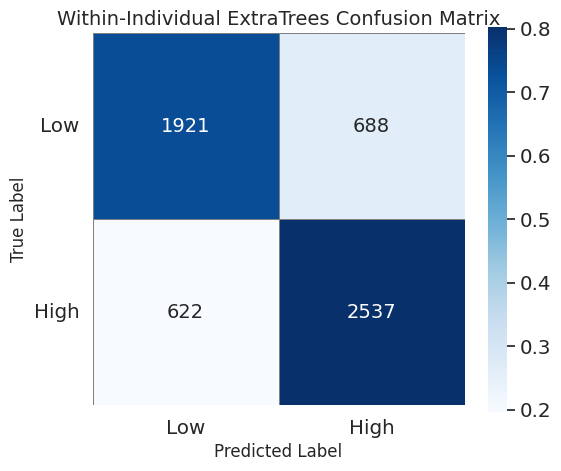

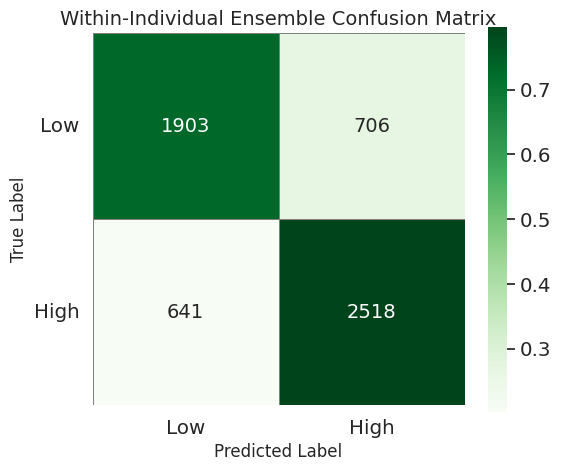

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Paths to your prediction CSVs
best_model_pred_file = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_RESULTS/V4_WITHIN_ExtraTrees_predictions.csv"  # replace with your best model
ensemble_pred_file = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_ENSEMBLE_RESULTS/V4_WITHIN_Ensemble_predictions.csv"

# Load predictions
best_pred_df = pd.read_csv(best_model_pred_file)
ensemble_pred_df = pd.read_csv(ensemble_pred_file)

# Function to plot confusion matrix with cool colors
def plot_confusion_matrix(df, title="Confusion Matrix", cmap="coolwarm"):
    y_true = df["true_label"]
    y_pred = df["predicted_label"]
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=cm, fmt='g', cmap=cmap, cbar=True, square=True,
                annot_kws={"size":14}, linewidths=0.5, linecolor='gray')
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks([0.5,1.5], ["Low", "High"])
    plt.yticks([0.5,1.5], ["Low", "High"], rotation=0)
    plt.show()

# Plot Best Model Confusion Matrix
plot_confusion_matrix(best_pred_df, title="Within-Individual ExtraTrees Confusion Matrix", cmap="Blues")

# Plot Ensemble Confusion Matrix
plot_confusion_matrix(ensemble_pred_df, title="Within-Individual Ensemble Confusion Matrix", cmap="Greens")

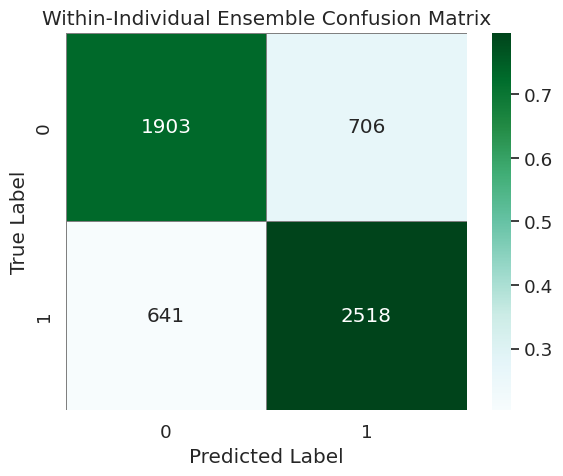

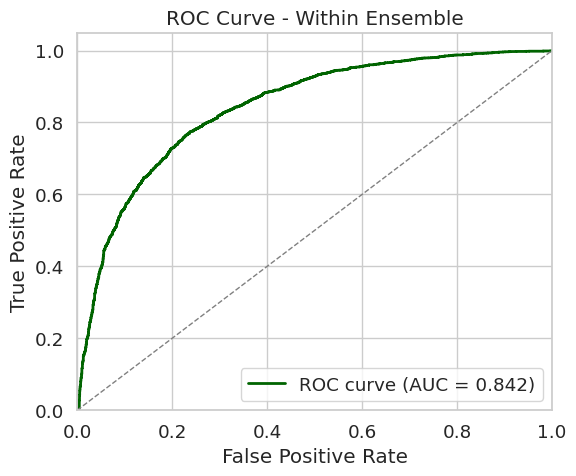

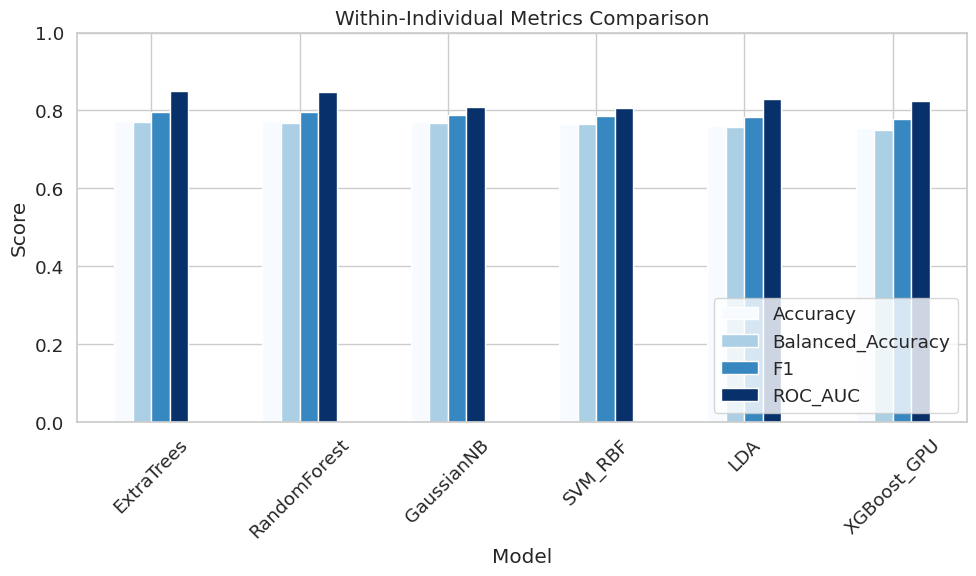

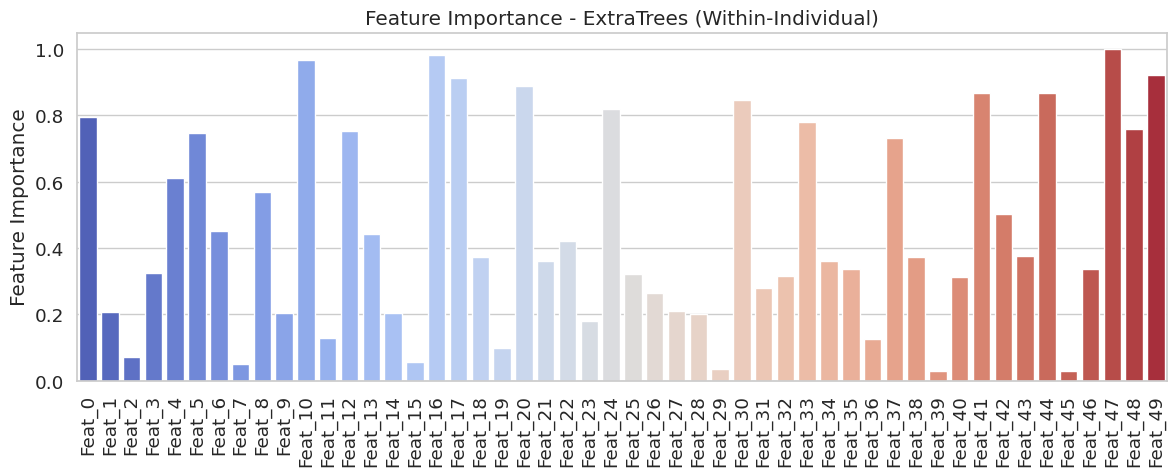

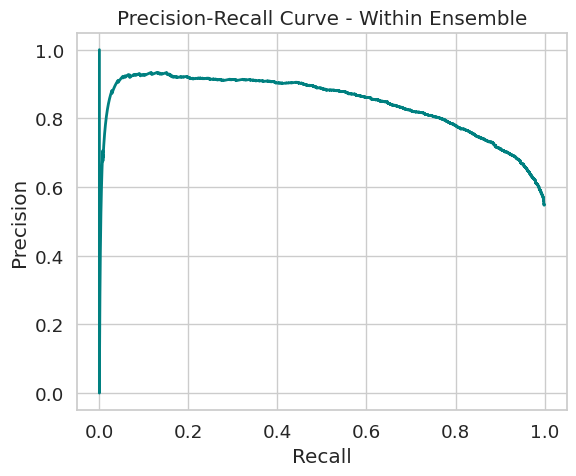

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10,6)

# ------------------------------
# Load prediction data
# ------------------------------
# Example: within-individual ensemble predictions
within_pred_file = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_ENSEMBLE_RESULTS/V4_WITHIN_Ensemble_predictions.csv"
pred_df = pd.read_csv(within_pred_file)

y_true = pred_df['true_label']
y_pred = pred_df['predicted_label']
y_prob = pred_df['probability']

# ------------------------------
# Confusion matrix (cool colors)
# ------------------------------
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=cm, fmt='g', cmap="BuGn", cbar=True, linewidths=0.5, linecolor='gray')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Within-Individual Ensemble Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------
# ROC Curve
# ------------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='grey', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Within Ensemble')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ------------------------------
# Metrics bar chart for multiple models
# ------------------------------
# Example: load the within-individual summary for all models
within_summary_file = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_RESULTS/V4_WITHIN_ALL_CLASSIFIER_COMPARISON.csv"
df = pd.read_csv(within_summary_file)

metrics = ['Accuracy', 'Balanced_Accuracy', 'F1', 'ROC_AUC']
df_plot = df.set_index('Model')[metrics]

df_plot.plot(kind='bar', figsize=(10,6), rot=45, cmap='Blues')
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Within-Individual Metrics Comparison")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ------------------------------
# Feature importance (ExtraTrees example)
# ------------------------------
# Load feature importance CSV (or compute from model)
feat_file = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/V4_WITHIN_RESULTS/V4_WITHIN_ExtraTrees_summary.csv"
# Assuming you have feature_importances_ array from trained model:
# feat_importances = model.feature_importances_

# Example placeholder
feat_importances = np.random.rand(50)  # replace with actual feature_importances_
features = [f"Feat_{i}" for i in range(len(feat_importances))]

plt.figure(figsize=(12,5))
sns.barplot(x=features, y=feat_importances, palette="coolwarm")
plt.xticks(rotation=90)
plt.ylabel("Feature Importance")
plt.title("Feature Importance - ExtraTrees (Within-Individual)")
plt.tight_layout()
plt.show()

# ------------------------------
# Precision-Recall curve (optional)
# ------------------------------
precision, recall, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='teal', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Within Ensemble')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Assume you already have X_norm (10x3000), X_pain (10x1000), X_hand_norm (230), X_riem (275)
# and the fused X_v4 (291 features)

# Define feature indices in the fused array
handcrafted_features = 230       # normalized hand-crafted
riemannian_features = 275        # Riemannian features
# CSP / other features: the remainder
# In your X_v4, it looks like you fused handcrafted + CSP + Riemannian
# Let's see the mapping

print("Total features in X_v4:", X_v4.shape[1])

# Since X_hand_norm=230, X_riem=275, but X_v4=291, then likely:
# first 230 -> normalized hand-crafted
# next (291-230-?) -> CSP
# last 275 -> Riemannian
# But 230 + 275 = 505 > 291, so your fusion is not simply concatenation, maybe some PCA/reduction

# Display feature indices
feature_names = []
for i in range(X_v4.shape[1]):
    if i < 230:
        feature_names.append(f"Norm_Feature_{i+1}")
    elif i >= 230 and i < 230+X_v4.shape[1]-230-275:
        feature_names.append(f"CSP_Feature_{i+1-230}")
    else:
        feature_names.append(f"Riemannian_Feature_{i+1-(X_v4.shape[1]-275)}")

# Convert to DataFrame to inspect
import pandas as pd
feat_df = pd.DataFrame({
    "Feature_Index": np.arange(1, X_v4.shape[1]+1),
    "Feature_Name": feature_names
})

pd.set_option('display.max_rows', None)
display(feat_df)

Total features in X_v4: 291


,Feature_Index,Feature_Name
0,1,Norm_Feature_1
1,2,Norm_Feature_2
2,3,Norm_Feature_3
3,4,Norm_Feature_4
4,5,Norm_Feature_5
5,6,Norm_Feature_6
6,7,Norm_Feature_7
7,8,Norm_Feature_8
8,9,Norm_Feature_9
9,10,Norm_Feature_10


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from xgboost import XGBClassifier

sns.set(style="whitegrid", font_scale=1.2)

# -------------------------------
# Load feature names from uploaded file
# -------------------------------
feature_names_file = "/mnt/data/Pasted text(65).txt"  # uploaded file
with open(feature_names_file, "r") as f:
    feature_names = [line.strip() for line in f.readlines() if line.strip()]

print(f"Total features loaded: {len(feature_names)}")

# Ensure feature names match X_v4 dimension
if len(feature_names) != X_v4.shape[1]:
    raise ValueError(f"Feature count mismatch: {len(feature_names)} names vs {X_v4.shape[1]} features")

# Dictionary to store feature importance per model
feature_importances = {}

# -------------------------------
# EXTRA TREES
# -------------------------------
extra = ExtraTreesClassifier(n_estimators=500, random_state=42, n_jobs=-1)
extra.fit(X_v4, epoch_labels)
feat_imp_extra = pd.Series(extra.feature_importances_, index=feature_names)
feature_importances['ExtraTrees'] = feat_imp_extra.sort_values(ascending=False)

# -------------------------------
# RANDOM FOREST
# -------------------------------
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X_v4, epoch_labels)
feat_imp_rf = pd.Series(rf.feature_importances_, index=feature_names)
feature_importances['RandomForest'] = feat_imp_rf.sort_values(ascending=False)

# -------------------------------
# XGBOOST (CPU)
# -------------------------------
xgb = XGBClassifier(
    n_estimators=500, max_depth=3, learning_rate=0.03,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", random_state=42,
    n_jobs=-1, tree_method="hist"
)
xgb.fit(X_v4, epoch_labels)
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=feature_names)
feature_importances['XGBoost'] = feat_imp_xgb.sort_values(ascending=False)

# -------------------------------
# Plotting function
# -------------------------------
def plot_feature_importance(feat_series, model_name, top_n=20):
    plt.figure(figsize=(10,8))
    sns.barplot(x=feat_series.values[:top_n], y=feat_series.index[:top_n], palette="coolwarm")
    plt.title(f"{model_name} Feature Importance (Top {top_n})", fontsize=16)
    plt.xlabel("Importance", fontsize=14)
    plt.ylabel("Feature", fontsize=14)
    plt.tight_layout()
    plt.show()

# -------------------------------
# Plot top 20 features for each model
# -------------------------------
for model_name, feat_series in feature_importances.items():
    plot_feature_importance(feat_series, model_name, top_n=20)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/Pasted text(65).txt'